# Нейронная сеть прямого распространения (FFNN / TDNN)
**Задание №4:**
- **Вход НС:** Некоторый набор финансовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказание на **L** шагов вперёд одного из показателей.
- **Изменяемые параметры:** `M` — ширина окна наблюдения, `D` — глубина задержек, `Ns` — число элементов в скрытом слое.

## Теоретическая база

### Нейрон и функция активации

Базовый элемент FFNN — формальный нейрон. Он вычисляет взвешенную сумму входов и применяет к ней нелинейную функцию активации:

$$z = \sum_{i=1}^{n} w_i x_i + b, \qquad a = f(z)$$

В данной работе используется **ReLU** (Rectified Linear Unit):

$$f(z) = \max(0, z)$$

ReLU не насыщается при больших значениях, не страдает от затухания градиента и вычислительно дешевле сигмоиды.

### Прямое распространение

Для сети с одним скрытым слоем из $N_s$ нейронов:

$$\mathbf{h} = \text{ReLU}(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1), \qquad \hat{y} = \mathbf{w}_2^\top \mathbf{h} + b_2$$

где $\mathbf{W}_1 \in \mathbb{R}^{N_s \times n}$, $\mathbf{b}_1 \in \mathbb{R}^{N_s}$ — параметры скрытого слоя, $\mathbf{w}_2 \in \mathbb{R}^{N_s}$ — параметры выходного нейрона.

### Обратное распространение ошибки

Функция потерь — **MSE** (Mean Squared Error):

$$\mathcal{L} = \frac{1}{N}\sum_{k=1}^{N}(y_k - \hat{y}_k)^2$$

Параметры обновляются методом **Adam** — адаптивным градиентным спуском:

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \hat{m}_t$$

где $\hat{m}_t$, $\hat{v}_t$ — скользящие средние первого и второго моментов градиента.

### Формирование входного вектора (TDNN)

Для задачи прогнозирования временного ряда вход формируется как скользящее окно с задержками:

$$\mathbf{x}^{(t)} = \bigl[p_{t-M},\; p_{t-M+D},\; p_{t-M+2D},\; \ldots,\; p_{t-D}\bigr]$$

Параметры:
- $M$ — ширина окна (сколько дней истории берём)
- $D$ — шаг задержки внутри окна (прореживание)
- $L$ — горизонт прогноза (цель: $p_{t+L}$)

## Импорт библиотек и настройка GPU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf

# ── Настройка GPU (NVIDIA) ──────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f'✓ Найдено GPU: {len(gpus)}')
    for i, gpu in enumerate(gpus):
        print(f'  GPU {i}: {gpu.name}')
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✓ Память GPU будет выделяться по мере необходимости')
    except RuntimeError as e:
        print(f'⚠ Ошибка настройки памяти: {e}')
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f'✓ Активный GPU: {gpus[0].name}')
else:
    print('⚠ GPU не найдено, используется CPU')

USE_SAVED_MODEL = False  # True — загрузить модель из model.keras

# ── Базовые параметры ───────────────────────────────────────────────────────
M       = 30   # Ширина окна наблюдения (дней)
D       = 1    # Глубина задержек (шаг выборки внутри окна)
L       = 5    # Горизонт прогнозирования (дней вперёд)
NEURONS = 256  # Число нейронов в скрытом слое
EPOCHS  = 50   # Число эпох обучения
BATCH   = 32   # Размер мини-батча

print(f'\nПараметры модели:')
print(f'  M       = {M}   (ширина окна)')
print(f'  D       = {D}   (глубина задержек)')
print(f'  L       = {L}   (горизонт прогноза)')
print(f'  NEURONS = {NEURONS} (нейронов в скрытом слое)')
print(f'  EPOCHS  = {EPOCHS}')

2026-04-03 09:45:24.663473: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости
✓ Активный GPU: /physical_device:GPU:0

Параметры модели:
  M       = 30   (ширина окна)
  D       = 1   (глубина задержек)
  L       = 5   (горизонт прогноза)
  NEURONS = 256 (нейронов в скрытом слое)
  EPOCHS  = 50


## Загрузка данных

In [2]:
tickers = ['GC=F', 'SI=F']
data = yf.download(tickers, start='2020-01-01', progress=False)

gold   = data['Close']['GC=F']
silver = data['Close']['SI=F']
data   = pd.DataFrame({'gold': gold}).dropna()
data.head()

,gold
Date,
2020-01-02,1524.500000
2020-01-03,1549.199951
2020-01-06,1566.199951
2020-01-07,1571.800049
2020-01-08,1557.400024


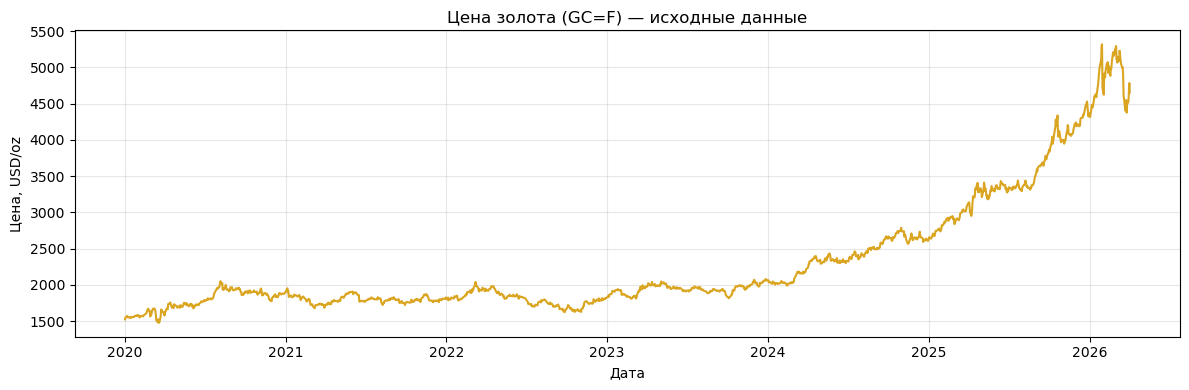

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data['gold'], color='goldenrod', linewidth=1.5)
plt.title('Цена золота (GC=F) — исходные данные')
plt.xlabel('Дата')
plt.ylabel('Цена, USD/oz')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Подготовка данных

In [4]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled

array([[0.01228813],
       [0.01871857],
       [0.02314439],
       ...,
       [0.82536257],
       [0.86066498],
       [0.82637788]])

In [5]:
def create_dataset(data, M, D, L):
    """
    Формирует обучающие пары (X, y) из временного ряда.

    Параметры
    ---------
    data : array-like, нормализованный временной ряд
    M    : int, ширина окна наблюдения
    D    : int, глубина задержек (шаг внутри окна)
    L    : int, горизонт прогноза

    Логика:
        Для каждого момента i строим D сдвинутых окон длины M
        и конкатенируем их в один вектор признаков.
        Цель — значение через M + D + L - 1 шагов.
    """
    X, y = [], []
    for i in range(len(data) - M - L - D):
        window = []
        for d in range(D):
            window.extend(data[i + d : i + d + M])
        X.append(window)
        y.append(data[i + M + D + L - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = create_dataset(data_scaled, M, D, L)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Обучающая: {len(X_train)}, Тестовая: {len(X_test)}')
print(f'\nКол-во признаков: {X_train.shape[1]}')

Обучающая: 1229, Тестовая: 308

Кол-во признаков: 30


## Создание модели FFNN

In [6]:
def build_model(input_size, neurons):
    """
    Строит FFNN с одним скрытым слоем.

    Архитектура:
        Input  → Dense(neurons, ReLU) → Dense(1, linear)

    Параметры
    ---------
    input_size : int, размерность входного вектора (M * D)
    neurons    : int, число нейронов в скрытом слое (Ns)
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_size,)),
        # Скрытый слой: neurons нейронов, активация ReLU
        # he_normal — инициализация весов, оптимальная для ReLU
        tf.keras.layers.Dense(
            neurons,
            activation='relu',
            kernel_initializer='he_normal'
        ),
        # Выходной нейрон без активации — регрессия (линейный выход)
        tf.keras.layers.Dense(1),
    ])
    # adam — адаптивный градиентный спуск
    # mse  — среднеквадратичная ошибка как функция потерь
    # mae  — средняя абсолютная ошибка как дополнительная метрика
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


model = build_model(X_train.shape[1], NEURONS)
model.summary()
# Число параметров:
#   Скрытый слой: X_train.shape[1] * NEURONS + NEURONS (bias)
#   Выходной слой: NEURONS * 1 + 1 (bias)

I0000 00:00:1775198727.154146    2668 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:2b:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,193 (32.00 KB)

 Trainable params: 8,193 (32.00 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [7]:
if USE_SAVED_MODEL:
    model = tf.keras.models.load_model('model.keras')
    print('✓ Модель загружена из model.keras')
else:
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH,
        verbose=1
    )
    model.save('model.keras')
    print('✓ Модель сохранена в model.keras')

Epoch 1/50


2026-04-03 09:45:28.661343: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ec4ec006940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-03 09:45:28.661379: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-04-03 09:45:28.753393: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-03 09:45:28.853959: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


27/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0096 - mae: 0.0704

I0000 00:00:1775198729.445826    2750 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0032 - mae: 0.0377 - val_loss: 0.0033 - val_mae: 0.0394
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5846e-04 - mae: 0.0128 - val_loss: 0.0022 - val_mae: 0.0335
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9765e-04 - mae: 0.0111 - val_loss: 0.0021 - val_mae: 0.0338
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8882e-04 - mae: 0.0108 - val_loss: 0.0024 - val_mae: 0.0373
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8570e-04 - mae: 0.0107 - val_loss: 0.0020 - val_mae: 0.0322
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0471e-04 - mae: 0.0112 - val_loss: 0.0023 - val_mae: 0.0367
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8264e-04 - mae: 0.0106 - val_loss: 0.0021 - val_mae: 0.0316
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8573e-04 - mae: 0.0106 - val_loss: 0.0020 - val_mae: 0.0325
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

## Результаты базового обучения

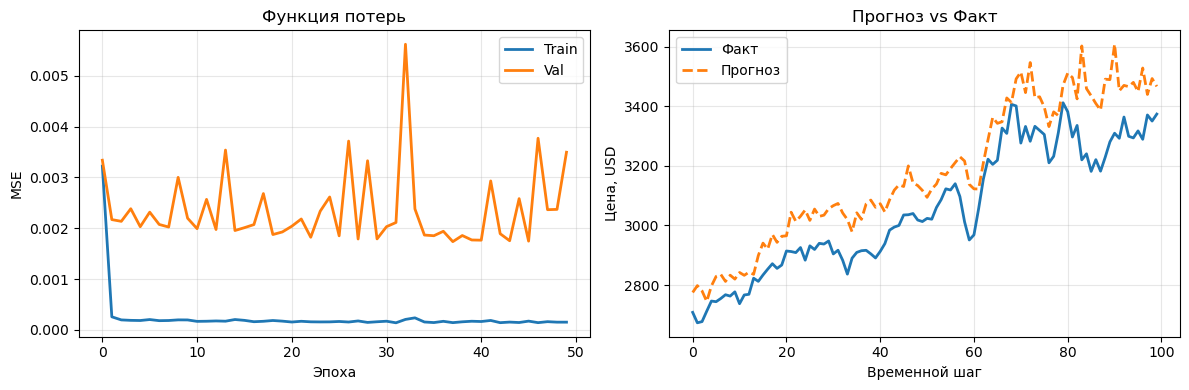

RMSE: 227.14 USD
R²:   0.8981


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Val',   linewidth=2)
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

y_pred = model.predict(X_test, verbose=0).flatten()
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

plt.subplot(1, 2, 2)
plt.plot(y_test_real[:100],        label='Факт',    linewidth=2)
plt.plot(y_pred_real[L:100 + L],  label='Прогноз', linewidth=2, linestyle='--')
plt.title('Прогноз vs Факт')
plt.xlabel('Временной шаг')
plt.ylabel('Цена, USD')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real[:len(y_test_real)]))
r2   = r2_score(y_test_real, y_pred_real[:len(y_test_real)])
print(f'RMSE: {rmse:.2f} USD')
print(f'R²:   {r2:.4f}')

## Работа над ошибками
Построить графики зависимостей *Loss* от M / L / D / NEURONS, проанализировать переобучение для данной задачи.

### Вспомогательные функции для экспериментов

In [9]:
def train_model(data, M, D, L, neurons, epochs=30):
    """
    Полный цикл: подготовка данных → построение модели → обучение.

    Возвращает модель и объект history для анализа потерь.
    """
    X, y = create_dataset(data, M, D, L)
    if len(X) < 50:
        return None, None, None, None, None, None

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )
    model = build_model(X.shape[1], neurons)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        verbose=0
    )
    return model, history, X_train, X_val, y_train, y_val


def plot_loss_vs_param(param_values, loss_train, loss_val, param_name):
    """Строит итоговый val_loss и train_loss vs значение параметра."""
    plt.figure(figsize=(10, 5))
    plt.plot(param_values, loss_train, 'o--', label='Train Loss', linewidth=2)
    plt.plot(param_values, loss_val,   's-',  label='Val Loss',   linewidth=2)
    plt.title(f'Loss vs {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('MSE (финальная эпоха)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(histories, param_values, param_name):
    """Строит кривые обучения для всех значений параметра на одном графике."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cmap = plt.get_cmap('viridis', len(param_values))

    for idx, (val, hist) in enumerate(zip(param_values, histories)):
        if hist is None:
            continue
        c = cmap(idx)
        axes[0].plot(hist.history['loss'],     color=c, linestyle='--', alpha=0.7)
        axes[0].plot(hist.history['val_loss'], color=c, label=f'{param_name}={val}', linewidth=1.8)

    axes[0].set_title(f'Кривые потерь при варьировании {param_name}')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('MSE')
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(True, alpha=0.3)

    vals_ok  = [v for v, h in zip(param_values, histories) if h is not None]
    tr_final = [h.history['loss'][-1]     for h in histories if h is not None]
    vl_final = [h.history['val_loss'][-1] for h in histories if h is not None]

    x_pos = np.arange(len(vals_ok))
    w = 0.35
    axes[1].bar(x_pos - w/2, tr_final, w, label='Train Loss', alpha=0.85)
    axes[1].bar(x_pos + w/2, vl_final, w, label='Val Loss',   alpha=0.85)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(v) for v in vals_ok])
    axes[1].set_title(f'Итоговые потери vs {param_name}')
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Влияние параметра {param_name} на функцию потерь',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print('✓ Вспомогательные функции определены')

✓ Вспомогательные функции определены


### Фиксированные базовые значения

In [10]:
M_fixed       = 30
D_fixed       = 1
L_fixed       = 5
NEURONS_fixed = 256

print(f'Базовые значения: M={M_fixed}, D={D_fixed}, L={L_fixed}, NEURONS={NEURONS_fixed}')

Базовые значения: M=30, D=1, L=5, NEURONS=256


### График зависимости Loss от M (ширины окна)

  M=  5  train=0.00015  val=0.00341
  M= 10  train=0.00016  val=0.00426
  M= 20  train=0.00014  val=0.00226
  M= 30  train=0.00015  val=0.00196


2026-04-03 09:46:04.807292: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:04.807359: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:05.700101: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 36 bytes spill stores, 36 bytes spill loads

2026-04-03 09:46:05.796941: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  M= 50  train=0.00016  val=0.00356


2026-04-03 09:46:13.547693: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:13.547749: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:14.362075: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_251', 36 bytes spill stores, 36 bytes spill loads

2026-04-03 09:46:14.893970: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

  M= 70  train=0.00017  val=0.00167


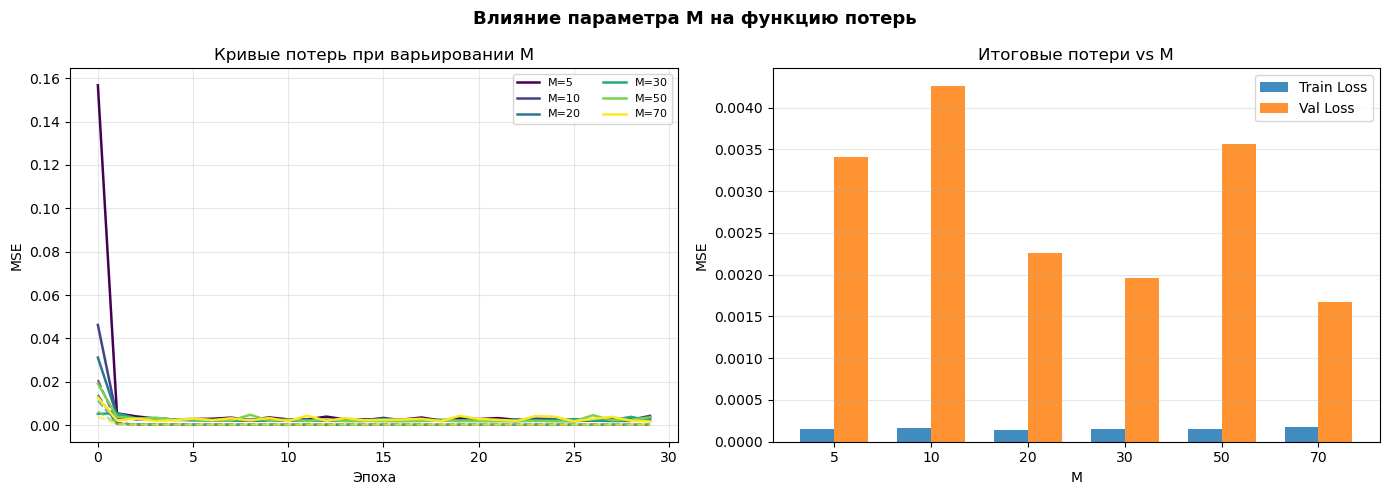

In [11]:
M_values   = [5, 10, 20, 30, 50, 70]
histories_M = []

for M_val in M_values:
    _, hist, *_ = train_model(
        data_scaled.flatten(), M_val, D_fixed, L_fixed, NEURONS_fixed, epochs=30
    )
    histories_M.append(hist)
    if hist:
        print(f'  M={M_val:>3}  train={hist.history["loss"][-1]:.5f}  val={hist.history["val_loss"][-1]:.5f}')

plot_loss_curves(histories_M, M_values, 'M')

### График зависимости Loss от D (глубины задержек)

  D=  1  train=0.00017  val=0.00207


2026-04-03 09:46:29.812285: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:29.812357: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:30.992099: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_251', 372 bytes spill stores, 372 bytes spill loads

2026-04-03 09:46:31.202707: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

  D=  2  train=0.00017  val=0.00301


2026-04-03 09:46:38.864730: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:38.864787: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:39.912732: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 40 bytes spill stores, 40 bytes spill loads

2026-04-03 09:46:40.092350: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  D=  3  train=0.00025  val=0.00366


...

  D=  5  train=0.00023  val=0.00235


2026-04-03 09:46:57.420494: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:57.420549: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:46:57.841535: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 12 bytes spill stores, 12 bytes spill loads

2026-04-03 09:46:58.520724: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  D=  7  train=0.00020  val=0.00209


2026-04-03 09:47:06.245877: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:47:06.245936: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-03 09:47:07.348241: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_251', 28 bytes spill stores, 28 bytes spill loads

2026-04-03 09:47:07.602721: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

  D= 10  train=0.00026  val=0.00465


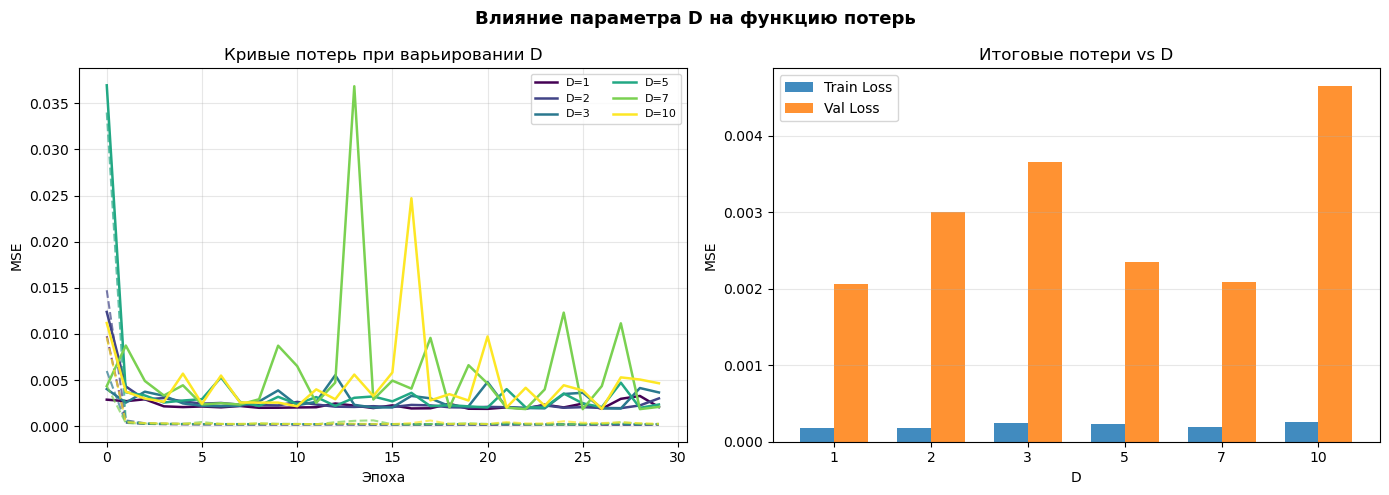

In [12]:
D_values    = [1, 2, 3, 5, 7, 10]
histories_D = []

for D_val in D_values:
    _, hist, *_ = train_model(
        data_scaled.flatten(), M_fixed, D_val, L_fixed, NEURONS_fixed, epochs=30
    )
    histories_D.append(hist)
    if hist:
        print(f'  D={D_val:>3}  train={hist.history["loss"][-1]:.5f}  val={hist.history["val_loss"][-1]:.5f}')

plot_loss_curves(histories_D, D_values, 'D')

### График зависимости Loss от L (горизонта прогноза)

  L=  1  train=0.00006  val=0.00081
  L=  2  train=0.00009  val=0.00224
  L=  3  train=0.00011  val=0.00157
  L=  5  train=0.00021  val=0.00331
  L=  7  train=0.00020  val=0.00235
  L= 10  train=0.00025  val=0.00335


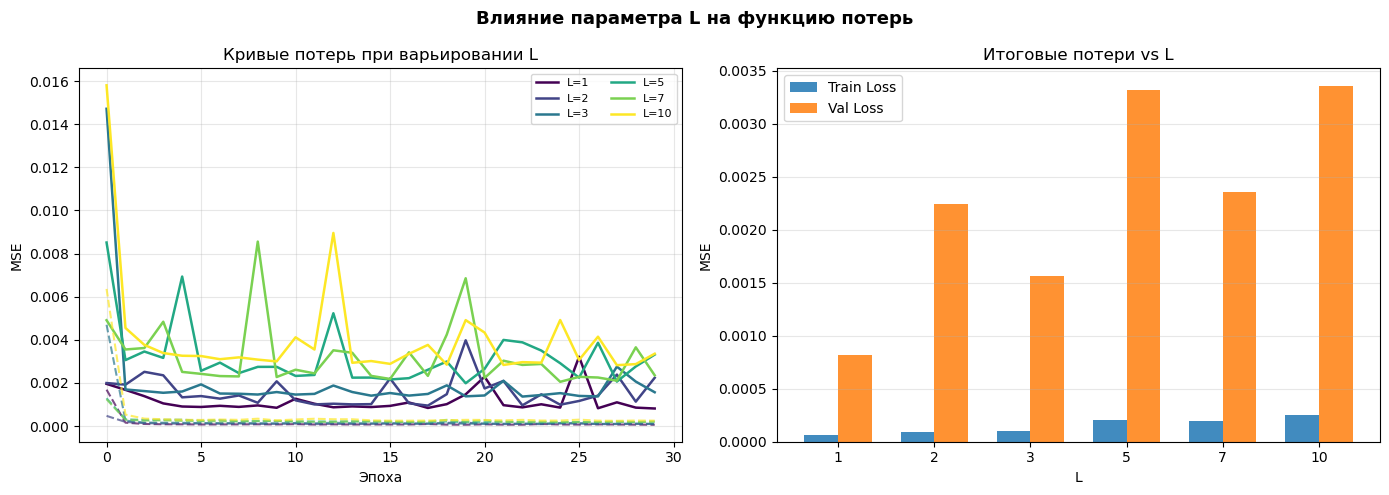

In [13]:
L_values    = [1, 2, 3, 5, 7, 10]
histories_L = []

for L_val in L_values:
    _, hist, *_ = train_model(
        data_scaled.flatten(), M_fixed, D_fixed, L_val, NEURONS_fixed, epochs=30
    )
    histories_L.append(hist)
    if hist:
        print(f'  L={L_val:>3}  train={hist.history["loss"][-1]:.5f}  val={hist.history["val_loss"][-1]:.5f}')

plot_loss_curves(histories_L, L_values, 'L')

### График зависимости Loss от числа нейронов (Ns)
Попытаемся найти переобучение — модель становится слишком сложной для данных.

  Ns=    8  train=0.00023  val=0.00247
  Ns=   16  train=0.00020  val=0.00244
  Ns=   32  train=0.00026  val=0.00291
  Ns=   64  train=0.00016  val=0.00190
  Ns=  128  train=0.00016  val=0.00203
  Ns=  256  train=0.00018  val=0.00194
  Ns=  512  train=0.00013  val=0.00186
  Ns= 1024  train=0.00019  val=0.00182


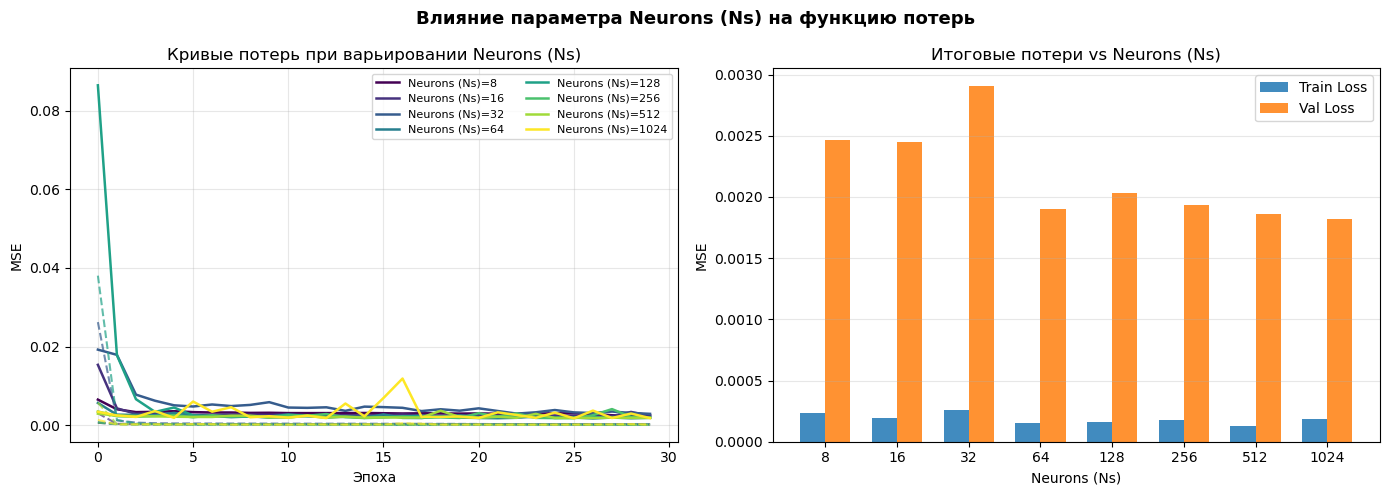

In [14]:
NEURONS_values = [8, 16, 32, 64, 128, 256, 512, 1024]
histories_N    = []

for N_val in NEURONS_values:
    _, hist, *_ = train_model(
        data_scaled.flatten(), M_fixed, D_fixed, L_fixed, N_val, epochs=30
    )
    histories_N.append(hist)
    if hist:
        print(f'  Ns={N_val:>5}  train={hist.history["loss"][-1]:.5f}  val={hist.history["val_loss"][-1]:.5f}')

plot_loss_curves(histories_N, NEURONS_values, 'Neurons (Ns)')

## Демонстрация переобучения

Переобучение вызывается намеренно через:
- **Очень большой скрытый слой** (Ns=2048 параметров — модель слишком мощная)
- **Малое окно M=5** — мало обучающих образцов
- **Много эпох** без ранней остановки

Параметры для переобучения: M=5, Ns=2048, epochs=200
Обучающая выборка: 1249 образцов


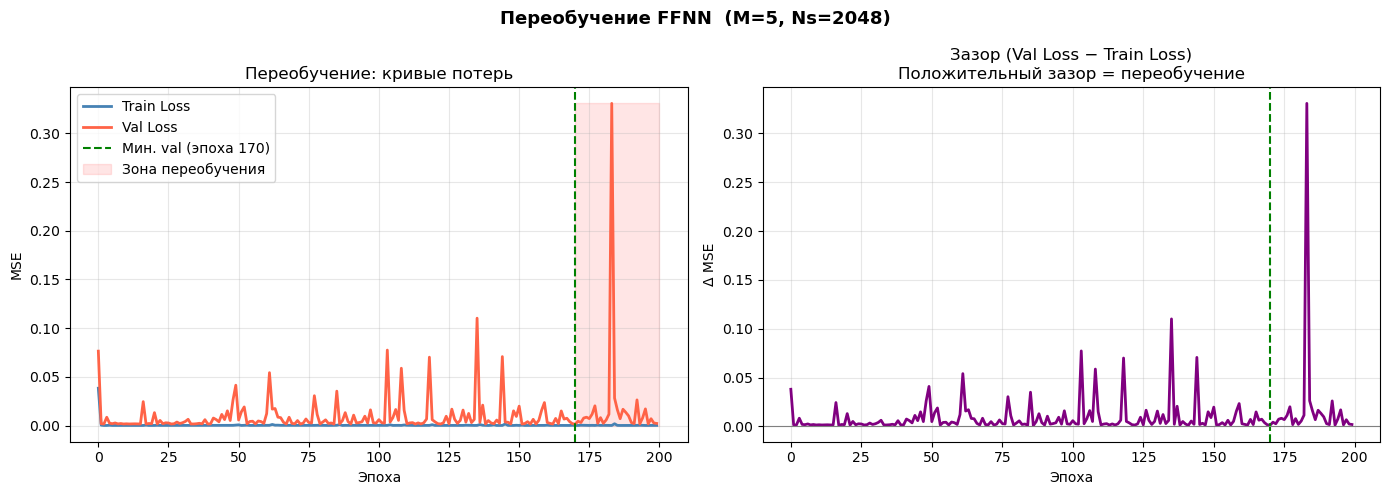


Минимальный val_loss на эпохе 170: 0.00158
Финальный train_loss: 0.00023  |  Финальный val_loss: 0.00224
Зазор переобучения:   0.00201


In [15]:
M_of      = 5      # Маленькое окно → мало данных и признаков
NEURONS_of = 2048  # Огромный слой → много параметров
EPOCHS_of  = 200   # Много эпох, без EarlyStopping

print(f'Параметры для переобучения: M={M_of}, Ns={NEURONS_of}, epochs={EPOCHS_of}')

X_of, y_of = create_dataset(data_scaled.flatten(), M_of, D_fixed, L_fixed)
X_tr_of, X_te_of, y_tr_of, y_te_of = train_test_split(
    X_of, y_of, test_size=0.2, shuffle=False
)
print(f'Обучающая выборка: {len(X_tr_of)} образцов')

overfit_model = build_model(X_of.shape[1], NEURONS_of)
overfit_hist  = overfit_model.fit(
    X_tr_of, y_tr_of,
    validation_data=(X_te_of, y_te_of),
    epochs=EPOCHS_of,
    batch_size=BATCH,
    verbose=0
)

tl_of = overfit_hist.history['loss']
vl_of = overfit_hist.history['val_loss']
best_epoch = int(np.argmin(vl_of))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tl_of, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(vl_of, label='Val Loss',   color='tomato',    linewidth=2)
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.5,
                label=f'Мин. val (эпоха {best_epoch})')
axes[0].fill_betweenx(
    [0, max(vl_of[:best_epoch*2] if best_epoch else vl_of)],
    best_epoch, EPOCHS_of,
    alpha=0.1, color='red', label='Зона переобучения'
)
axes[0].set_title('Переобучение: кривые потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

gap = np.array(vl_of) - np.array(tl_of)
axes[1].plot(gap, color='purple', linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1.5)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Зазор (Val Loss − Train Loss)\nПоложительный зазор = переобучение')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Δ MSE')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Переобучение FFNN  (M={M_of}, Ns={NEURONS_of})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nМинимальный val_loss на эпохе {best_epoch}: {min(vl_of):.5f}')
print(f'Финальный train_loss: {tl_of[-1]:.5f}  |  Финальный val_loss: {vl_of[-1]:.5f}')
print(f'Зазор переобучения:   {vl_of[-1] - tl_of[-1]:.5f}')

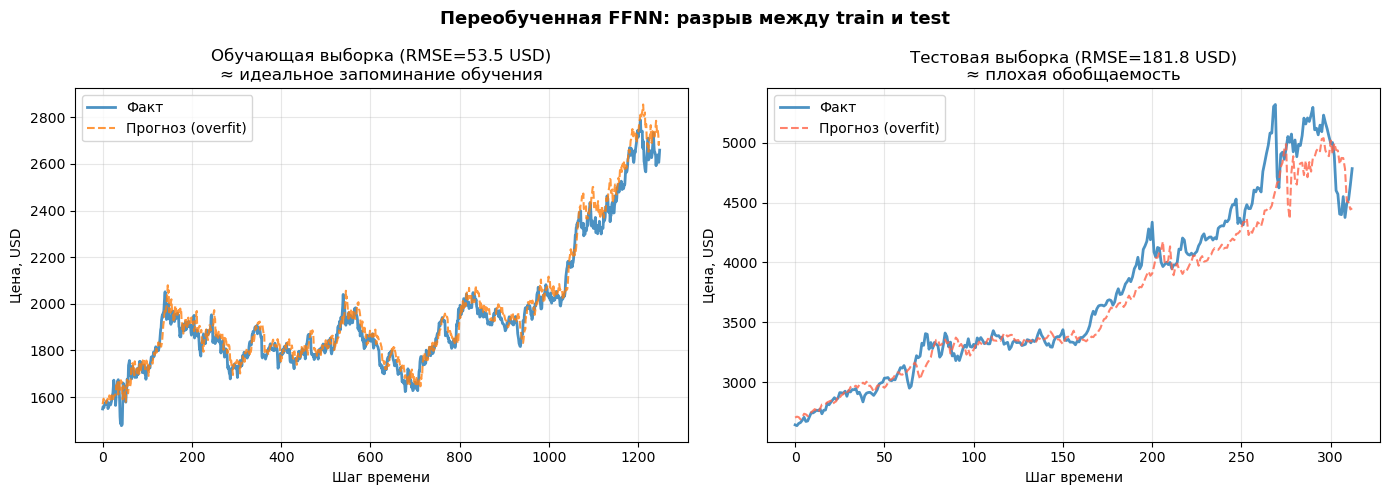

In [16]:
# Наглядное сравнение прогнозов: переобученная модель
y_pred_of_train = overfit_model.predict(X_tr_of, verbose=0).flatten()
y_pred_of_test  = overfit_model.predict(X_te_of, verbose=0).flatten()

def inv(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(inv(y_tr_of),          label='Факт',             alpha=0.8, linewidth=2)
axes[0].plot(inv(y_pred_of_train),  label='Прогноз (overfit)',alpha=0.8, linewidth=1.5, linestyle='--')
rmse_tr = np.sqrt(mean_squared_error(inv(y_tr_of), inv(y_pred_of_train)))
axes[0].set_title(f'Обучающая выборка (RMSE={rmse_tr:.1f} USD)\n≈ идеальное запоминание обучения')
axes[0].set_xlabel('Шаг времени')
axes[0].set_ylabel('Цена, USD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(inv(y_te_of),          label='Факт',             alpha=0.8, linewidth=2)
axes[1].plot(inv(y_pred_of_test),   label='Прогноз (overfit)',alpha=0.8, linewidth=1.5,
             linestyle='--', color='tomato')
rmse_te = np.sqrt(mean_squared_error(inv(y_te_of), inv(y_pred_of_test)))
axes[1].set_title(f'Тестовая выборка (RMSE={rmse_te:.1f} USD)\n≈ плохая обобщаемость')
axes[1].set_xlabel('Шаг времени')
axes[1].set_ylabel('Цена, USD')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Переобученная FFNN: разрыв между train и test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Финальный прогноз — базовая модель на полной тестовой выборке

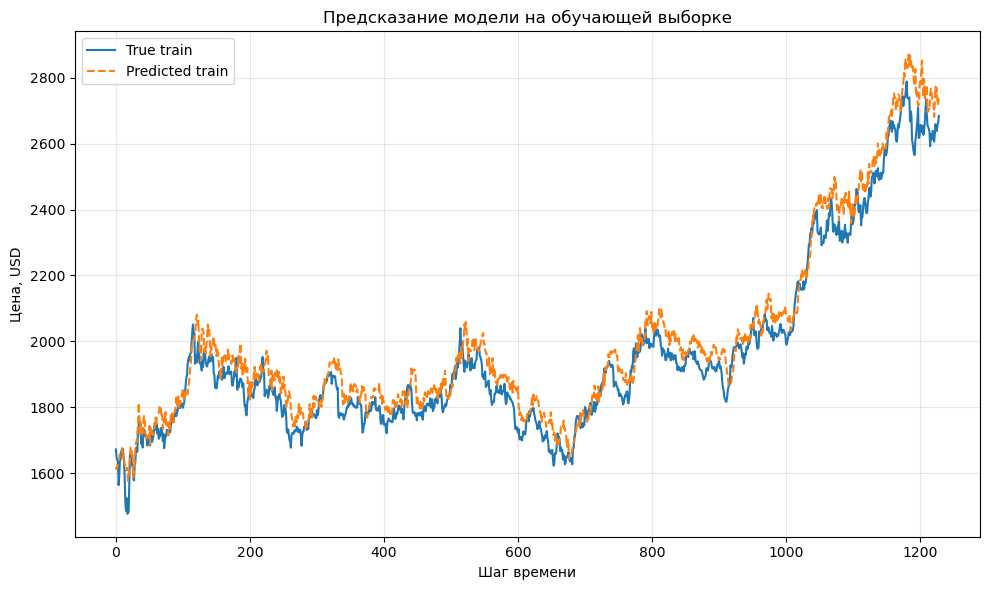

In [17]:
y_train_pred = model.predict(X_train, verbose=0).flatten()

plt.figure(figsize=(10, 6))
plt.plot(scaler.inverse_transform(y_train.reshape(-1,1)).flatten(),
         label='True train', linewidth=1.5)
plt.plot(scaler.inverse_transform(y_train_pred.reshape(-1,1)).flatten(),
         label='Predicted train', linewidth=1.5, linestyle='--')
plt.title('Предсказание модели на обучающей выборке')
plt.xlabel('Шаг времени')
plt.ylabel('Цена, USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()